# Bloch Sphere with colorbar

## Imports

In [3]:
import matplotlib as mpl
import numpy as np
from matplotlib import cm
from qutip import *

%matplotlib inline

## Do a closed Landau-Zener Evolution

In [4]:
delta = 0.5 * 2 * np.pi
v = 2.0 * 2 * np.pi # Sweep rate

H0 = delta / 2.0 * sigmax()
H1 = v / 2.0 * sigmaz()
H = [H0, [H1, "t"]]
psi0 = basis(2, 0)

sm = destroy(2)
sx = sigmax()
sy = sigmay()
sz = sigmaz()
expt_ops = [sm.dag() * sm, sx, sy, sz]

tlist = np.linspace(-10.0, 10.0, 1500)
expt_list = sesolve(H, psi0, tlist, expt_ops).expect
expt_list = [np.array(exp) for exp in expt_list]

/home/prem/VS Code/Learning/QuTip/.venv/lib/python3.13/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
/home/prem/VS Code/Learning/QuTip/.venv/lib/python3.13/site-packages/qutip/core/coefficient.py:424: UserWarning: `cython`, `setuptools` and `filelock` are required for compilation of string coefficents. Falling back on `eval`.
  warnings.warn(


## Generate a Bloch Sphere with Multi-Colored Points

Note that I need to call `b.show` here so that I can grab a Figure instance later

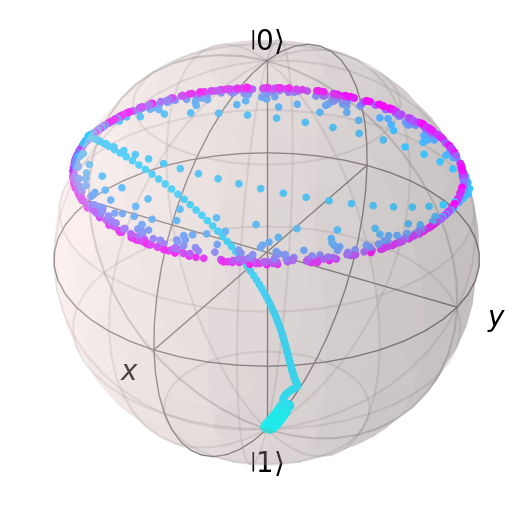

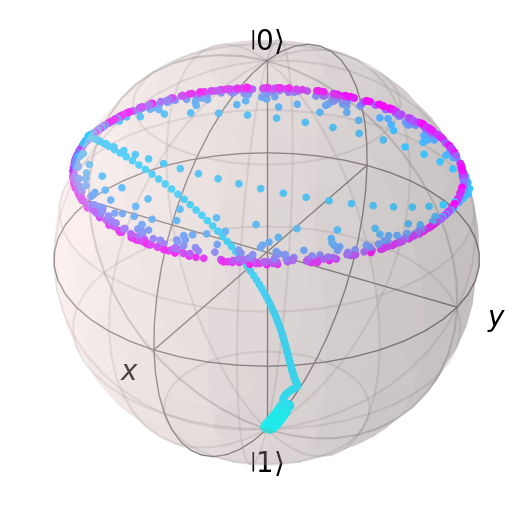

In [11]:
b = Bloch()
# Normalize colors to times in the tlist
nrm = mpl.colors.Normalize(-2, 10)
colors = cm.cool(nrm(tlist))

# add data points from expectation values
b.add_points([expt_list[1], expt_list[2], -expt_list[3]], "m")

# customize sphere properties
b.point_color = list(colors)
b.point_marker = ["o"]
b.point_size = [20]

b.zlpos = [1.1, -1.2]

b.show()

## Add New Axis to Bloch Figure

In [8]:
left, bottom, width, height = [0.98, 0.05, 0.05, 0.9]
ax2 = b.fig.add_axes([left, bottom, width, height])

mpl.colorbar.ColorbarBase(ax2, cmap=cm.cool, norm=nrm, orientation="vertical");

## Plot with Colorbar Added

Currently I need to call `b.fig` as replotting figures in a notebook is a bit tricky. However, this is likely to be improved in the future

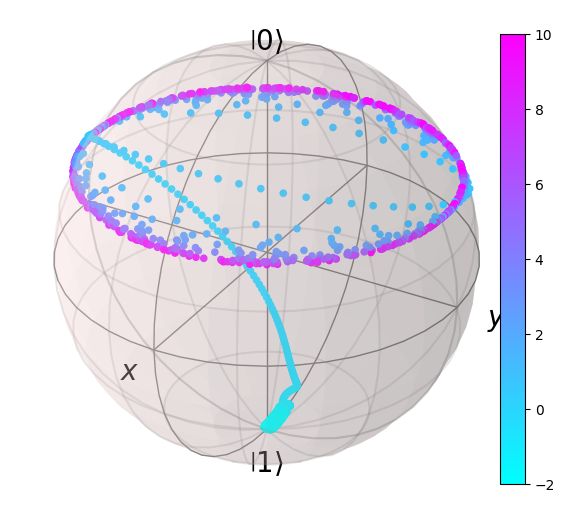

In [9]:
b.fig

In [ ]:
about()


QuTiP: Quantum Toolbox in Python
Copyright (c) QuTiP team 2011 and later.
Current admin team: Alexander Pitchford, Nathan Shammah, Shahnawaz Ahmed, Neill Lambert, Eric Giguère, Boxi Li, Simon Cross, Asier Galicia, Paul Menczel, and Patrick Hopf.
Board members: Daniel Burgarth, Robert Johansson, Anton F. Kockum, Franco Nori and Will Zeng.
Original developers: R. J. Johansson & P. D. Nation.
Previous lead developers: Chris Granade & A. Grimsmo.
Currently developed through wide collaboration. See https://github.com/qutip for details.

QuTiP Version:      5.2.3
Numpy Version:      2.4.4
Scipy Version:      1.17.1
Cython Version:     None
Matplotlib Version: 3.10.8
Python Version:     3.13.12
Number of CPUs:     8
BLAS Info:          scipy-openblas
INTEL MKL Ext:      None
Platform Info:      Linux (x86_64)
Installation path:  /home/prem/VS Code/Learning/QuTip/.venv/lib/python3.13/site-packages/qutip

Installed QuTiP family packages
-------------------------------

No QuTiP family packages